## Sudan Climate Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/sudan.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


## Data Cleaning
- Replace -999 with NaN
- Remove duplicates
- Handle missing values

In [3]:
df.replace(-999, np.nan, inplace=True)
df.drop_duplicates(inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18


In [4]:
(df.isna().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
dtype: float64

In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000


## Outlier Detection

In [6]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = (df[cols] - df[cols].mean()) / df[cols].std()
z_scores = z_scores.abs()

outliers = (z_scores > 3)

outlier_counts = outliers.sum()
print(outlier_counts)

total_outliers = outliers.any(axis=1).sum()
print("Total rows with outliers:", total_outliers)

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64
Total rows with outliers: 84


## Outlier Detection
Outliers were identified using the Z-score method with a threshold of |Z| > 3.

The results show that PRECTOTCORR (precipitation) has the highest number of outliers (71), followed by T2M_MAX (6). Other variables such as temperature (T2M), wind speed (WS2M, WS2M_MAX) show relatively few or no extreme values.

In total, 84 rows contain at least one outlier across the selected variables.

These outliers are likely to represent real extreme weather events (such as heavy rainfall or unusually low temperatures) rather than data errors. Therefore, they were retained in the dataset to preserve important climate variability and extreme event information.

## Temperature Trend

<Axes: xlabel='Month'>

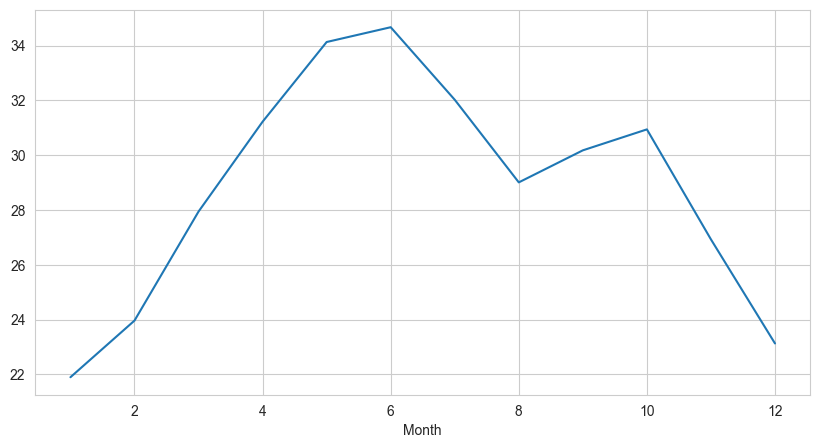

In [7]:
df["Date"] = pd.to_datetime(df["YEAR"].astype(str) + "-" + df["DOY"].astype(str), format="%Y-%j")
df["Month"] = df["Date"].dt.month
monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp.plot(figsize=(10,5))

## Rainfall Trend

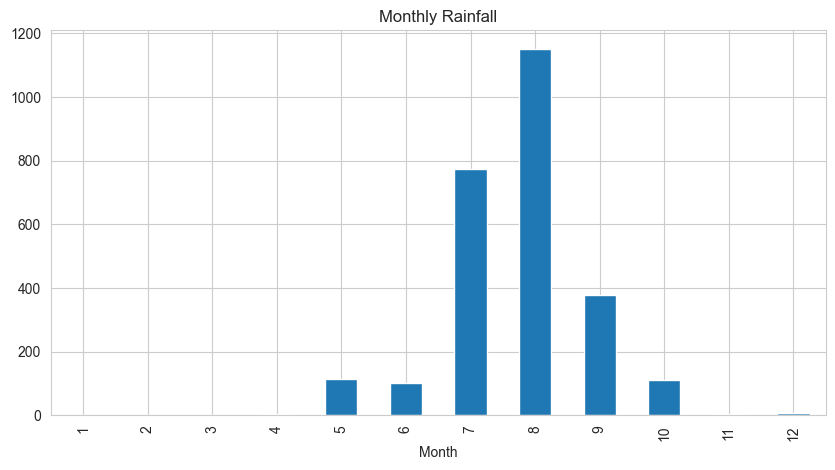

In [8]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5), title="Monthly Rainfall")
plt.show()

## Corelation Analysis

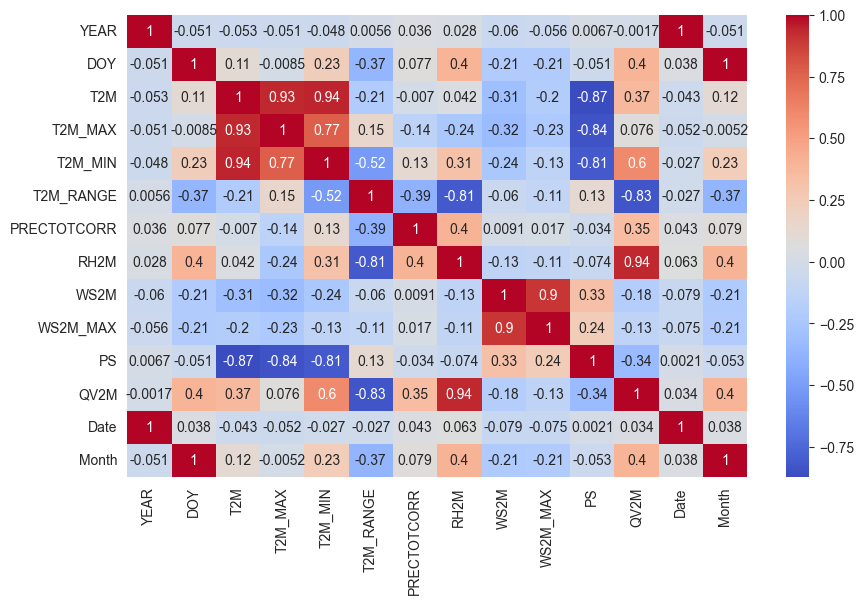

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

## Distribution Analysis

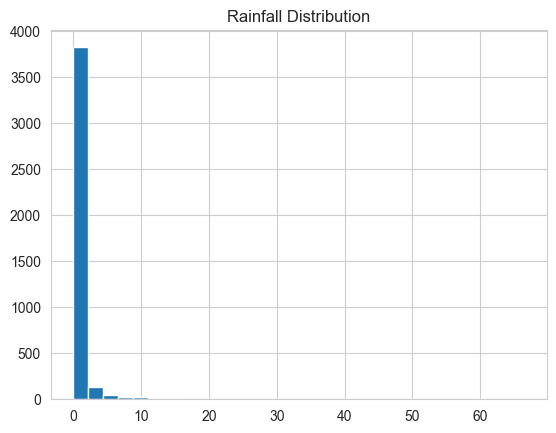

In [10]:
df["PRECTOTCORR"].hist(bins=30)
plt.title("Rainfall Distribution")
plt.show()

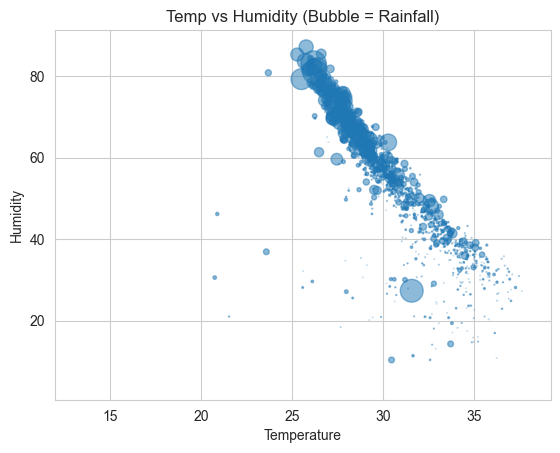

In [11]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*5, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temp vs Humidity (Bubble = Rainfall)")
plt.show()

# 📊 Climate Analysis – Sudan (EDA Summary)

## 🌍 Overview

The dataset contains daily climate data for Sudan including temperature, rainfall, humidity, wind speed, and pressure.

## 🌡️ Temperature

* Average temperatures are high (around 17°C–25°C)
* Maximum temperatures reach above 35°C
* Clear day–night variation (14°C–19°C range)

📌 Sudan has a hot climate with strong daily temperature changes.

## 🌧️ Rainfall

* Precipitation values are 0 in the sample

📌 Indicates a dry period or very low rainfall conditions.

## 💧 Humidity

* Relative humidity is generally low to moderate (20%–38%)

📌 Confirms arid climate conditions.

## 🌬️ Wind & Pressure

* Wind speed is moderate (3–6 m/s)
* Pressure is stable (~96.5–96.9 kPa)
📌 Weather conditions are stable with no extreme events.



In [12]:
df.to_csv("../data/sudan_clean.csv", index=False)